<a href="https://colab.research.google.com/github/Priyanshu5266/Network-Science-practical/blob/main/Priyanshu_question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 2. Closeness Centrality Analysis: Using Zachary's Karate Club and the Dolphin Social Network
datasets, analyze and compare the closeness centrality of individuals without using
nx.closeness_centrality() or NetworkX shortest-path functions.**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
karate= nx.karate_club_graph()

In [ ]:
print("Number of nodes:", karate.number_of_nodes())
print("Number of edges:", karate.number_of_edges())

Number of nodes: 34
Number of edges: 78


In [ ]:
dolphin = nx.read_gml("dolphins.gml", label=None)

In [ ]:
print("Number of nodes:", dolphin.number_of_nodes())
print("Number of edges:", dolphin.number_of_edges())

Number of nodes: 62
Number of edges: 159


In [ ]:
def bfs(G, start):
    distance = {start: 0}
    queue = deque([start])

    while queue:
        node = queue.popleft()

        for neighbour in G.neighbors(node):
            if neighbour not in distance:
                distance[neighbour] = distance[node] + 1
                queue.append(neighbour)
    return distance

In [ ]:
distances= bfs(karate,0)
print(distances)

{0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 10: 1, 11: 1, 12: 1, 13: 1, 17: 1, 19: 1, 21: 1, 31: 1, 30: 2, 9: 2, 27: 2, 28: 2, 32: 2, 16: 2, 33: 2, 24: 2, 25: 2, 23: 3, 14: 3, 15: 3, 18: 3, 20: 3, 22: 3, 29: 3, 26: 3}


In [ ]:
def closeness(G):
    result = {}
    N = G.number_of_nodes()

    for node in G.nodes():
        distances = bfs(G, node)
        total = sum(distances.values())
        result[node] = (N - 1) / total
    return result

In [ ]:
karate_close = closeness(karate)
print(karate_close)

{0: 0.5689655172413793, 1: 0.4852941176470588, 2: 0.559322033898305, 3: 0.4647887323943662, 4: 0.3793103448275862, 5: 0.38372093023255816, 6: 0.38372093023255816, 7: 0.44, 8: 0.515625, 9: 0.4342105263157895, 10: 0.3793103448275862, 11: 0.36666666666666664, 12: 0.3707865168539326, 13: 0.515625, 14: 0.3707865168539326, 15: 0.3707865168539326, 16: 0.28448275862068967, 17: 0.375, 18: 0.3707865168539326, 19: 0.5, 20: 0.3707865168539326, 21: 0.375, 22: 0.3707865168539326, 23: 0.39285714285714285, 24: 0.375, 25: 0.375, 26: 0.3626373626373626, 27: 0.4583333333333333, 28: 0.4520547945205479, 29: 0.38372093023255816, 30: 0.4583333333333333, 31: 0.5409836065573771, 32: 0.515625, 33: 0.55}


Ranking Analysis: Calculate and display the closeness centrality of all nodes and identify the
top 5 most centrally positioned nodes in each network.

In [ ]:
top5 = sorted(
    karate_close.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

print("Top 5 nodes:")

for node, value in top5:
    print(node, round(value, 4))

Top 5 nodes:
0 0.569
2 0.5593
33 0.55
31 0.541
8 0.5156


In [ ]:
dolphin_close = closeness(dolphin)

print(dolphin_close)

{0: 0.3465909090909091, 1: 0.3719512195121951, 2: 0.2824074074074074, 3: 0.30808080808080807, 4: 0.24897959183673468, 5: 0.23828125, 6: 0.2675438596491228, 7: 0.3652694610778443, 8: 0.3630952380952381, 9: 0.25206611570247933, 10: 0.3128205128205128, 11: 0.24897959183673468, 12: 0.2687224669603524, 13: 0.27111111111111114, 14: 0.3765432098765432, 15: 0.3388888888888889, 16: 0.32972972972972975, 17: 0.3096446700507614, 18: 0.3370165745856354, 19: 0.3160621761658031, 20: 0.391025641025641, 21: 0.3333333333333333, 22: 0.23735408560311283, 23: 0.3333333333333333, 24: 0.3128205128205128, 25: 0.25523012552301255, 26: 0.2772727272727273, 27: 0.3160621761658031, 28: 0.3652694610778443, 29: 0.32275132275132273, 30: 0.32275132275132273, 31: 0.23735408560311283, 32: 0.21631205673758866, 33: 0.3652694610778443, 34: 0.3160621761658031, 35: 0.24497991967871485, 36: 0.4178082191780822, 37: 0.39869281045751637, 38: 0.32972972972972975, 39: 0.33516483516483514, 40: 0.40397350993377484, 41: 0.29756097560

In [ ]:
top5_dolphin = sorted(
    dolphin_close.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

print("Top 5 Dolphin Nodes:")

for node, value in top5_dolphin:
    print(node, round(value, 4))

Top 5 Dolphin Nodes:
36 0.4178
40 0.404
37 0.3987
20 0.391
14 0.3765


In [ ]:
print("Karate Club Ranking")

rank = 1

for node, value in sorted(karate_close.items(), key=lambda x: x[1], reverse=True):
    print(rank, node, value)
    rank += 1

Karate Club Ranking
1 0 0.5689655172413793
2 2 0.559322033898305
3 33 0.55
4 31 0.5409836065573771
5 8 0.515625
6 13 0.515625
7 32 0.515625
8 19 0.5
9 1 0.4852941176470588
10 3 0.4647887323943662
11 27 0.4583333333333333
12 30 0.4583333333333333
13 28 0.4520547945205479
14 7 0.44
15 9 0.4342105263157895
16 23 0.39285714285714285
17 5 0.38372093023255816
18 6 0.38372093023255816
19 29 0.38372093023255816
20 4 0.3793103448275862
21 10 0.3793103448275862
22 17 0.375
23 21 0.375
24 24 0.375
25 25 0.375
26 12 0.3707865168539326
27 14 0.3707865168539326
28 15 0.3707865168539326
29 18 0.3707865168539326
30 20 0.3707865168539326
31 22 0.3707865168539326
32 11 0.36666666666666664
33 26 0.3626373626373626
34 16 0.28448275862068967


In [ ]:
print("Dolphin Network Ranking")

rank = 1

for node, value in sorted(dolphin_close.items(), key=lambda x: x[1], reverse=True):
    print(rank, node, value)
    rank += 1

Dolphin Network Ranking
1 36 0.4178082191780822
2 40 0.40397350993377484
3 37 0.39869281045751637
4 20 0.391025641025641
5 14 0.3765432098765432
6 1 0.3719512195121951
7 7 0.3652694610778443
8 28 0.3652694610778443
9 33 0.3652694610778443
10 8 0.3630952380952381
11 50 0.3505747126436782
12 0 0.3465909090909091
13 45 0.3465909090909091
14 52 0.34269662921348315
15 59 0.34269662921348315
16 15 0.3388888888888889
17 47 0.3388888888888889
18 18 0.3370165745856354
19 43 0.3370165745856354
20 39 0.33516483516483514
21 21 0.3333333333333333
22 23 0.3333333333333333
23 16 0.32972972972972975
24 38 0.32972972972972975
25 42 0.32972972972972975
26 51 0.32972972972972975
27 54 0.324468085106383
28 29 0.32275132275132273
29 30 0.32275132275132273
30 19 0.3160621761658031
31 27 0.3160621761658031
32 34 0.3160621761658031
33 10 0.3128205128205128
34 24 0.3128205128205128
35 44 0.3112244897959184
36 17 0.3096446700507614
37 3 0.30808080808080807
38 57 0.30198019801980197
39 61 0.30198019801980197
40 

3. Visual Analysis: Visualize both networks with node sizes proportional to the manually calculated
closeness centrality and identify the structurally central individuals.

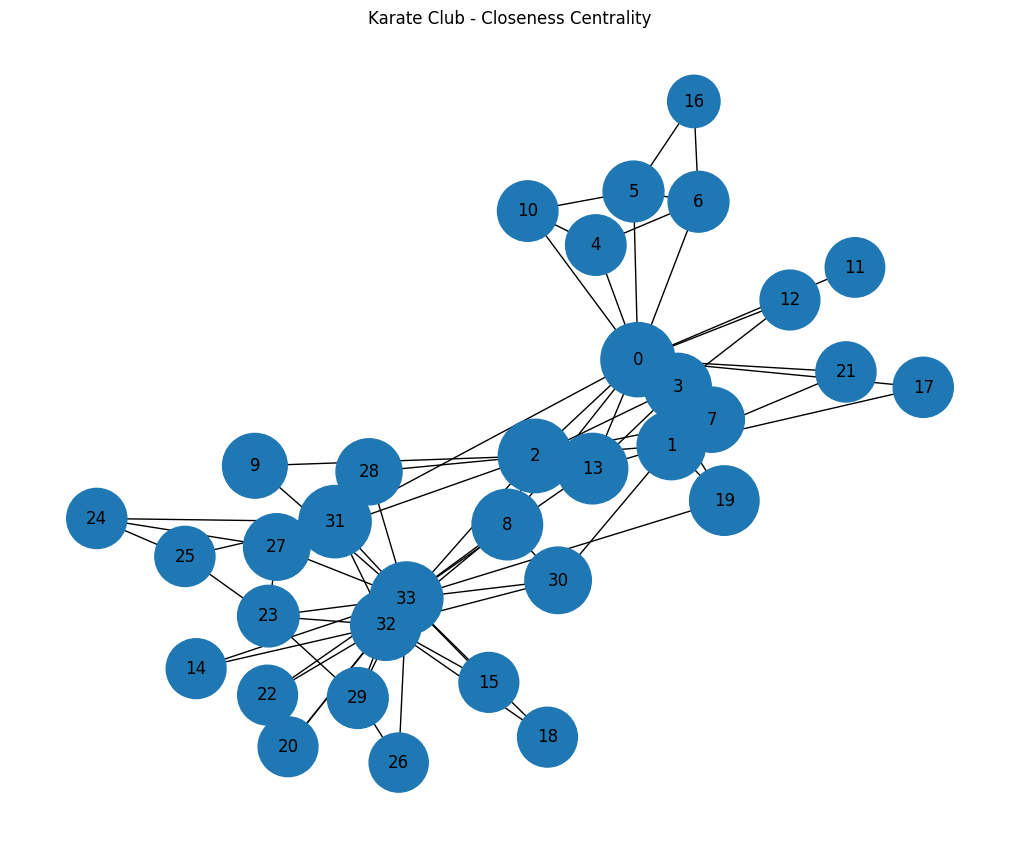

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(karate, seed=3)
sizes = []

for node in karate.nodes():
    sizes.append(karate_close[node] * 5000)
nx.draw(
    karate,
    pos,
    with_labels=True,
    node_size=sizes
)

plt.title("Karate Club - Closeness Centrality")
plt.show()

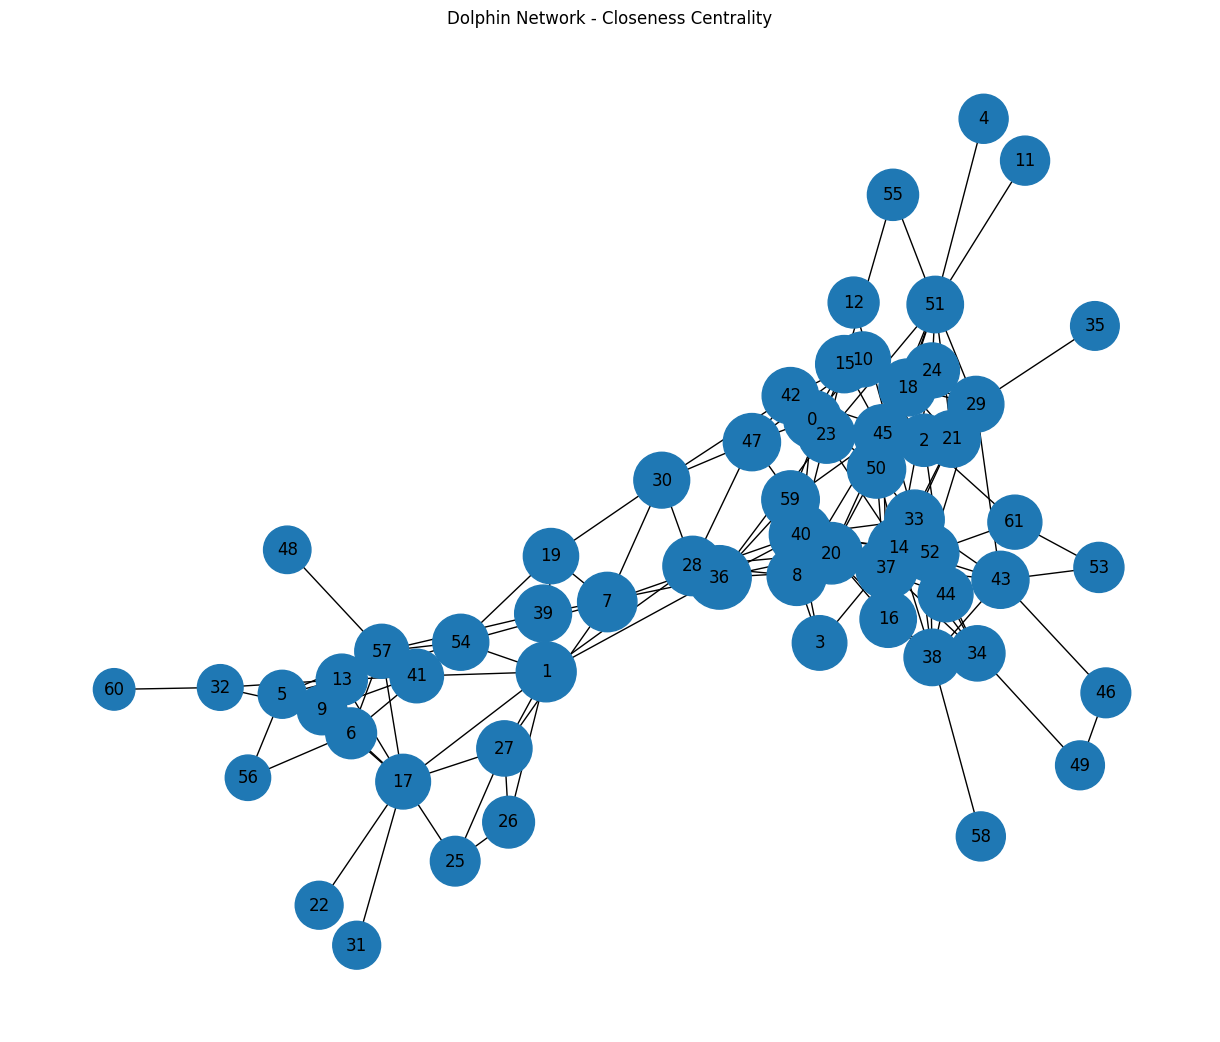

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(dolphin, seed=3)

sizes = []

for node in dolphin.nodes():
    sizes.append(dolphin_close[node] * 5000)

nx.draw(
    dolphin,
    pos,
    with_labels=True,
    node_size=sizes
)

plt.title("Dolphin Network - Closeness Centrality")
plt.show()

4. Comparative Challenge: Compare the node with the highest closeness centrality against the
node with the highest degree centrality in each dataset. Determine whether the same individual is
identified as most important and justify your answer using network structure.

In [ ]:
def degree_centrality(G):
    result = {}
    N = G.number_of_nodes()

    for node in G.nodes():
        degree = len(list(G.neighbors(node)))
        result[node] = degree / (N - 1)

    return result

In [ ]:
karate_degree = degree_centrality(karate)

highest_closeness = max(karate_close, key=karate_close.get)
highest_degree = max(karate_degree, key=karate_degree.get)
print("karate highest closeness:", highest_closeness)
print("karate highest degree:", highest_degree)

karate highest closeness: 0
karate highest degree: 33


In [ ]:
dolphin_degree = degree_centrality(dolphin)

highest_closeness = max(dolphin_close, key=dolphin_close.get)
highest_degree = max(dolphin_degree, key=dolphin_degree.get)
print("dolphin highest closeness:", highest_closeness)
print("dolphins highest Degree:", highest_degree)

dolphin highest closeness: 36
dolphins highest Degree: 14


5. Verification and Interpretation: Verify the manually calculated results using
nx.closeness_centrality() only after completing the implementation. Compare the top 5 rankings
across both networks and explain why individuals with high closeness centrality can spread
information efficiently.

In [ ]:
karate_nx = nx.closeness_centrality(karate)

for node in karate.nodes():
    print(
        node,
        "Manual =", karate_close[node],
        "NetworkX =", karate_nx[node]
    )

0 Manual = 0.5689655172413793 NetworkX = 0.5689655172413793
1 Manual = 0.4852941176470588 NetworkX = 0.4852941176470588
2 Manual = 0.559322033898305 NetworkX = 0.559322033898305
3 Manual = 0.4647887323943662 NetworkX = 0.4647887323943662
4 Manual = 0.3793103448275862 NetworkX = 0.3793103448275862
5 Manual = 0.38372093023255816 NetworkX = 0.38372093023255816
6 Manual = 0.38372093023255816 NetworkX = 0.38372093023255816
7 Manual = 0.44 NetworkX = 0.44
8 Manual = 0.515625 NetworkX = 0.515625
9 Manual = 0.4342105263157895 NetworkX = 0.4342105263157895
10 Manual = 0.3793103448275862 NetworkX = 0.3793103448275862
11 Manual = 0.36666666666666664 NetworkX = 0.36666666666666664
12 Manual = 0.3707865168539326 NetworkX = 0.3707865168539326
13 Manual = 0.515625 NetworkX = 0.515625
14 Manual = 0.3707865168539326 NetworkX = 0.3707865168539326
15 Manual = 0.3707865168539326 NetworkX = 0.3707865168539326
16 Manual = 0.28448275862068967 NetworkX = 0.28448275862068967
17 Manual = 0.375 NetworkX = 0.375


In [ ]:
dolphin_nx = nx.closeness_centrality(dolphin)

for node in dolphin.nodes():
    print(
        node,
        "Manual =", dolphin_close[node],
        "NetworkX =", dolphin_nx[node],
    )

0 Manual = 0.3465909090909091 NetworkX = 0.3465909090909091
1 Manual = 0.3719512195121951 NetworkX = 0.3719512195121951
2 Manual = 0.2824074074074074 NetworkX = 0.2824074074074074
3 Manual = 0.30808080808080807 NetworkX = 0.30808080808080807
4 Manual = 0.24897959183673468 NetworkX = 0.24897959183673468
5 Manual = 0.23828125 NetworkX = 0.23828125
6 Manual = 0.2675438596491228 NetworkX = 0.2675438596491228
7 Manual = 0.3652694610778443 NetworkX = 0.3652694610778443
8 Manual = 0.3630952380952381 NetworkX = 0.3630952380952381
9 Manual = 0.25206611570247933 NetworkX = 0.25206611570247933
10 Manual = 0.3128205128205128 NetworkX = 0.3128205128205128
11 Manual = 0.24897959183673468 NetworkX = 0.24897959183673468
12 Manual = 0.2687224669603524 NetworkX = 0.2687224669603524
13 Manual = 0.27111111111111114 NetworkX = 0.27111111111111114
14 Manual = 0.3765432098765432 NetworkX = 0.3765432098765432
15 Manual = 0.3388888888888889 NetworkX = 0.3388888888888889
16 Manual = 0.32972972972972975 NetworkX

In [ ]:
print("TOP 5 CLOSENESS CENTRALITY")
print()

print("Karate Club:")
for rank, (node, value) in enumerate(top5, 1):
    print(rank, "Node:", node, "Closeness:", round(value, 4))

print()

print("Dolphin Network:")
for rank, (node, value) in enumerate(top5_dolphin, 1):
    print(rank, "Node:", node, "Closeness:", round(value, 4))

TOP 5 CLOSENESS CENTRALITY

Karate Club:
1 Node: 0 Closeness: 0.569
2 Node: 2 Closeness: 0.5593
3 Node: 33 Closeness: 0.55
4 Node: 31 Closeness: 0.541
5 Node: 8 Closeness: 0.5156

Dolphin Network:
1 Node: 36 Closeness: 0.4178
2 Node: 40 Closeness: 0.404
3 Node: 37 Closeness: 0.3987
4 Node: 20 Closeness: 0.391
5 Node: 14 Closeness: 0.3765
